In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import string
import os
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [43]:
TRAIN_PATH = "twitter_training.csv"
VALIDATION_PATH = "twitter_validation.csv"

train_df = pd.read_csv(
    TRAIN_PATH,
    header=None
)

validation_df = pd.read_csv(
    VALIDATION_PATH,
    header=None
)

print("Training dataset shape:", train_df.shape)
print("Validation dataset shape:", validation_df.shape)

Training dataset shape: (74682, 4)
Validation dataset shape: (1000, 4)


In [44]:
columns = [
    "id",
    "entity",
    "sentiment",
    "text"
]

train_df.columns = columns
validation_df.columns = columns

print("Training columns:")
print(train_df.columns.tolist())

print("\nTraining data:")
display(train_df.head())

print("\nValidation data:")
display(validation_df.head())
 
 

Training columns:
['id', 'entity', 'sentiment', 'text']

Training data:


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Validation data:


,id,entity,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [45]:
print("Training sentiment distribution:")
print(train_df["sentiment"].value_counts())

print("\nValidation sentiment distribution:")
print(validation_df["sentiment"].value_counts())

Training sentiment distribution:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Validation sentiment distribution:
sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64


In [46]:
# Remove missing values
train_df = train_df.dropna(subset=["text", "sentiment"])
validation_df = validation_df.dropna(subset=["text", "sentiment"])

# Remove Irrelevant class
train_df = train_df[
    train_df["sentiment"].str.strip().str.lower() != "irrelevant"
].copy()

validation_df = validation_df[
    validation_df["sentiment"].str.strip().str.lower() != "irrelevant"
].copy()

print("Training classes:")
print(train_df["sentiment"].value_counts())

print("\nValidation classes:")
print(validation_df["sentiment"].value_counts())

Training classes:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64

Validation classes:
sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64


In [47]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove mentions
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Remove hashtag symbol
    text = re.sub(
        r"#",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove numbers
    text = re.sub(
        r"\d+",
        "",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [48]:
train_df["clean_text"] = train_df["text"].apply(
    clean_text
)

validation_df["clean_text"] = validation_df["text"].apply(
    clean_text
)

display(
    train_df[
        ["text", "clean_text", "sentiment"]
    ].head(10)
)

,text,clean_text,sentiment
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,Positive
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,Positive
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,Positive
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...,Positive
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,Positive
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...,Positive
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...,Positive
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,Positive


In [49]:
train_df = train_df[
    train_df["clean_text"].str.strip() != ""
].copy()

validation_df = validation_df[
    validation_df["clean_text"].str.strip() != ""
].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))

Training samples: 60688
Validation samples: 828


In [50]:
X_train = train_df["clean_text"]
y_train = train_df["sentiment"].astype(str).str.strip()

X_validation = validation_df["clean_text"]
y_validation = validation_df["sentiment"].astype(str).str.strip()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

X_train: (60688,)
y_train: (60688,)
X_validation: (828,)
y_validation: (828,)


In [51]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [52]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_validation_tfidf = tfidf.transform(
    X_validation
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF shape:",
    X_validation_tfidf.shape
)

print(
    "Vectorizer fitted:",
    hasattr(tfidf, "idf_")
)

print(
    "Vocabulary size:",
    len(tfidf.vocabulary_)
)

Training TF-IDF shape: (60688, 50000)
Validation TF-IDF shape: (828, 50000)
Vectorizer fitted: True
Vocabulary size: 50000


In [53]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_pred = logistic_model.predict(
    X_validation_tfidf
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [54]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_validation_tfidf
)

print("Linear SVM training completed.")

Linear SVM training completed.


In [55]:
logistic_accuracy = accuracy_score(
    y_validation,
    logistic_pred
)

logistic_precision = precision_score(
    y_validation,
    logistic_pred,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_validation,
    logistic_pred,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_validation,
    logistic_pred,
    average="weighted"
)

print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    "Accuracy:",
    round(logistic_accuracy, 4)
)

print(
    "Precision:",
    round(logistic_precision, 4)
)

print(
    "Recall:",
    round(logistic_recall, 4)
)

print(
    "F1 Score:",
    round(logistic_f1, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        logistic_pred,
        zero_division=0
    )
)

LOGISTIC REGRESSION
Accuracy: 0.9807
Precision: 0.9807
Recall: 0.9807
F1 Score: 0.9807

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       266
     Neutral       0.99      0.97      0.98       285
    Positive       0.97      0.99      0.98       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



In [56]:
svm_accuracy = accuracy_score(
    y_validation,
    svm_pred
)

svm_precision = precision_score(
    y_validation,
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_recall = recall_score(
    y_validation,
    svm_pred,
    average="weighted",
    zero_division=0
)

svm_f1 = f1_score(
    y_validation,
    svm_pred,
    average="weighted"
)

print("LINEAR SVM")
print("=" * 50)

print(
    "Accuracy:",
    round(svm_accuracy, 4)
)

print(
    "Precision:",
    round(svm_precision, 4)
)

print(
    "Recall:",
    round(svm_recall, 4)
)

print(
    "F1 Score:",
    round(svm_f1, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        svm_pred,
        zero_division=0
    )
)

LINEAR SVM
Accuracy: 0.9843
Precision: 0.9844
Recall: 0.9843
F1 Score: 0.9843

Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99       266
     Neutral       0.99      0.98      0.98       285
    Positive       0.98      0.99      0.98       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        svm_recall
    ],
    "F1 Score": [
        logistic_f1,
        svm_f1
    ]
})

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.9843,0.9844,0.9843,0.9843
1,Logistic Regression,0.9807,0.9807,0.9807,0.9807


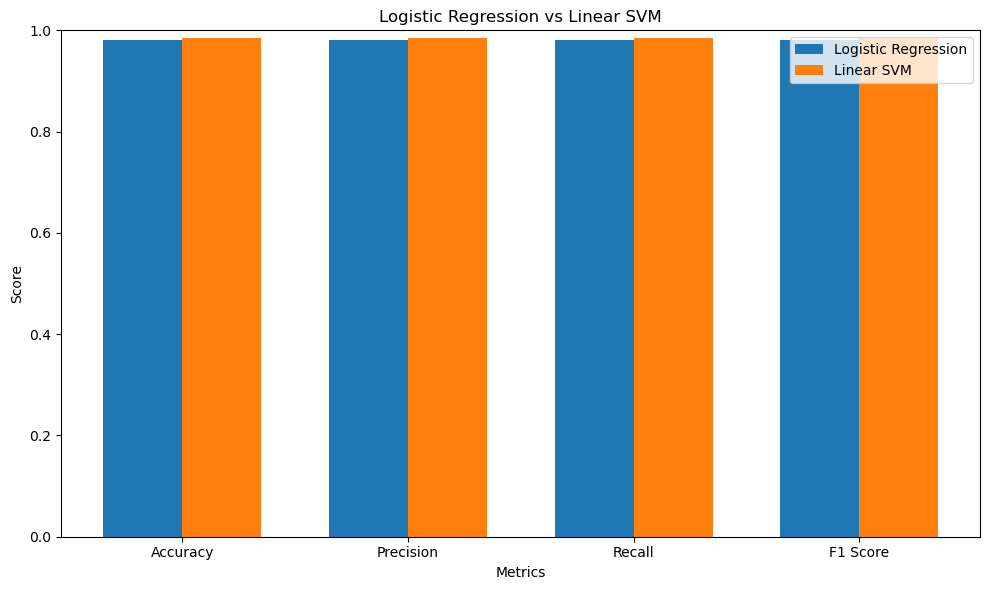

In [58]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1
    ],
    width,
    label="Logistic Regression"
)

ax.bar(
    x + width / 2,
    [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ],
    width,
    label="Linear SVM"
)

ax.set_xlabel("Metrics")
ax.set_ylabel("Score")
ax.set_title("Logistic Regression vs Linear SVM")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

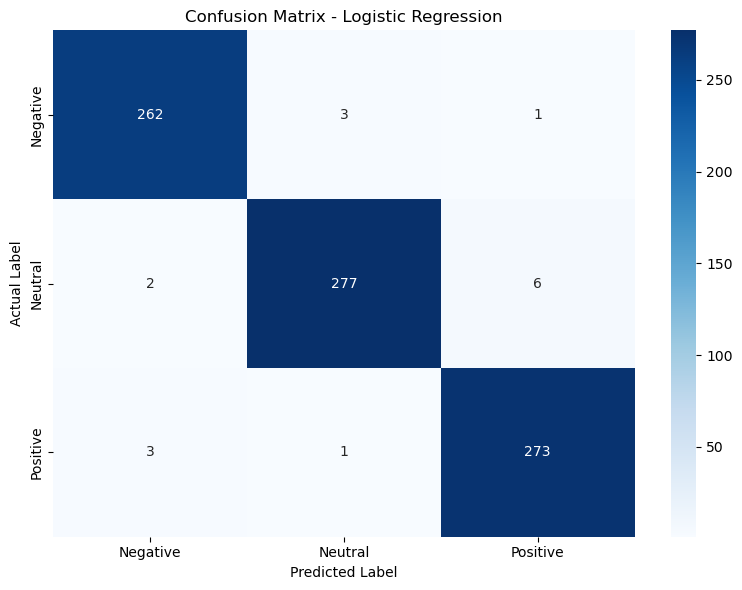

In [59]:
labels = sorted(
    y_validation.unique()
)

logistic_cm = confusion_matrix(
    y_validation,
    logistic_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

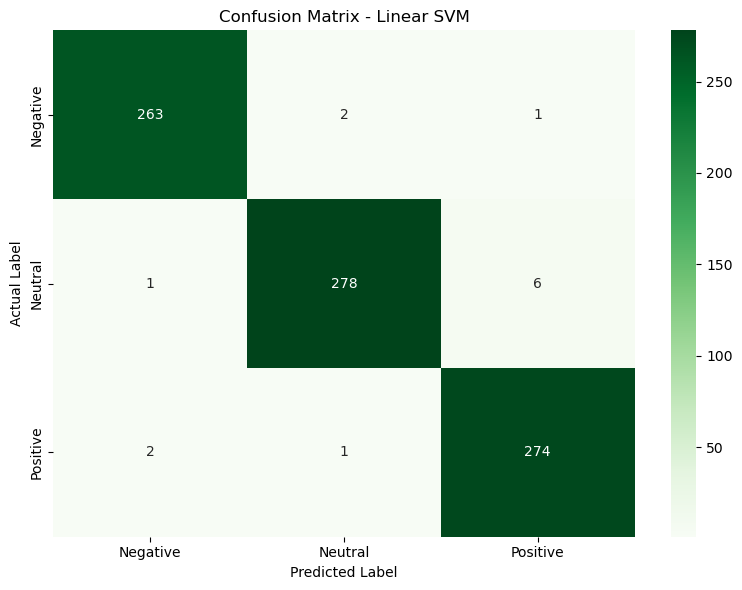

In [60]:
svm_cm = confusion_matrix(
    y_validation,
    svm_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix - Linear SVM"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [61]:
if svm_f1 > logistic_f1:
    best_model = svm_model
    best_model_name = "Linear SVM"
    best_predictions = svm_pred
    best_f1 = svm_f1
    best_accuracy = svm_accuracy

else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_predictions = logistic_pred
    best_f1 = logistic_f1
    best_accuracy = logistic_accuracy

print("BEST MODEL")
print("=" * 50)
print("Model:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))
print("F1 Score:", round(best_f1, 4))

BEST MODEL
Model: Linear SVM
Accuracy: 0.9843
F1 Score: 0.9843


In [62]:
print(
    classification_report(
        y_validation,
        best_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99       266
     Neutral       0.99      0.98      0.98       285
    Positive       0.98      0.99      0.98       277

    accuracy                           0.98       828
   macro avg       0.98      0.98      0.98       828
weighted avg       0.98      0.98      0.98       828



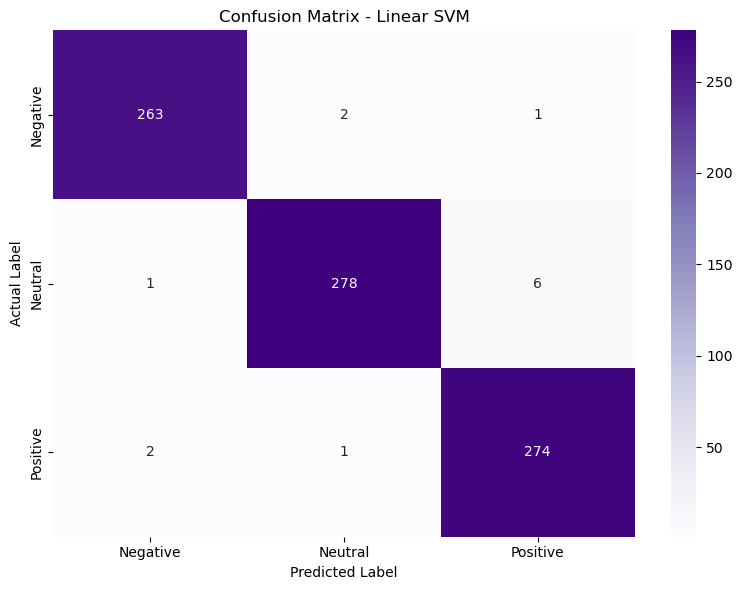

In [63]:
best_cm = confusion_matrix(
    y_validation,
    best_predictions,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [64]:
test_sentences = [
    "I absolutely love this!",
    "This is the worst experience ever.",
    "It is okay, nothing special.",
    "I don't really care about this.",
    "I am extremely happy today!",
    "This game is terrible and boring."
]

cleaned_sentences = [
    clean_text(text)
    for text in test_sentences
]

test_vectors = tfidf.transform(
    cleaned_sentences
)

test_predictions = best_model.predict(
    test_vectors
)

for text, prediction in zip(
    test_sentences,
    test_predictions
):
    print("Text:", text)
    print("Prediction:", prediction)
    print("-" * 60)

Text: I absolutely love this!
Prediction: Positive
------------------------------------------------------------
Text: This is the worst experience ever.
Prediction: Negative
------------------------------------------------------------
Text: It is okay, nothing special.
Prediction: Positive
------------------------------------------------------------
Text: I don't really care about this.
Prediction: Negative
------------------------------------------------------------
Text: I am extremely happy today!
Prediction: Positive
------------------------------------------------------------
Text: This game is terrible and boring.
Prediction: Negative
------------------------------------------------------------


In [65]:
def get_prediction_confidence(model, vectors):
    
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(vectors)
        confidence = np.max(
            probabilities,
            axis=1
        )
        return confidence

    else:
        decision_scores = model.decision_function(
            vectors
        )

        if decision_scores.ndim == 1:
            confidence = np.abs(
                decision_scores
            )
        else:
            confidence = np.max(
                decision_scores,
                axis=1
            )

        # Convert scores approximately to 0-1
        confidence = (
            1 /
            (
                1 +
                np.exp(-confidence)
            )
        )

        return confidence

In [66]:
MODEL_DIR = "models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "sentiment_model.pkl"
)

VECTORIZER_PATH = os.path.join(
    MODEL_DIR,
    "tfidf_vectorizer.pkl"
)

print("Model path:", MODEL_PATH)
print("Vectorizer path:", VECTORIZER_PATH)

Model path: models\sentiment_model.pkl
Vectorizer path: models\tfidf_vectorizer.pkl


In [67]:
joblib.dump(
    best_model,
    MODEL_PATH
)

print(
    "Best model saved successfully."
)

print(
    "Selected model:",
    best_model_name
)

Best model saved successfully.
Selected model: Linear SVM


In [68]:
joblib.dump(
    tfidf,
    VECTORIZER_PATH
)

print(
    "Fitted TF-IDF vectorizer saved successfully."
)

Fitted TF-IDF vectorizer saved successfully.


In [69]:
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_vectorizer = joblib.load(
    VECTORIZER_PATH
)

print("Model type:")
print(type(loaded_model))

print("\nVectorizer type:")
print(type(loaded_vectorizer))

print(
    "\nVectorizer fitted:",
    hasattr(
        loaded_vectorizer,
        "idf_"
    )
)

print(
    "Vocabulary size:",
    len(
        loaded_vectorizer.vocabulary_
    )
)

Model type:
<class 'sklearn.svm._classes.LinearSVC'>

Vectorizer type:
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>

Vectorizer fitted: True
Vocabulary size: 50000


In [71]:
sample_texts = [
    "I really love this product!",
    "This is absolutely horrible.",
    "It is just okay."
]

cleaned = [
    clean_text(text)
    for text in sample_texts
]

vectors = loaded_vectorizer.transform(
    cleaned
)

predictions = loaded_model.predict(
    vectors
)

confidences = get_prediction_confidence(
    loaded_model,
    vectors
)

for text, prediction, confidence in zip(
    sample_texts,
    predictions,
    confidences
):
    print("Text:", text)
    print("Prediction:", prediction)
    

Text: I really love this product!
Prediction: Positive
Text: This is absolutely horrible.
Prediction: Negative
Text: It is just okay.
Prediction: Negative


In [72]:
print("========== DEPLOYMENT CHECK ==========")

print(
    "Model exists:",
    os.path.exists(MODEL_PATH)
)

print(
    "Vectorizer exists:",
    os.path.exists(VECTORIZER_PATH)
)

print(
    "Vectorizer fitted:",
    hasattr(
        loaded_vectorizer,
        "idf_"
    )
)

print(
    "Vocabulary size:",
    len(
        loaded_vectorizer.vocabulary_
    )
)

print(
    "Best model:",
    best_model_name
)

print(
    "Validation accuracy:",
    round(
        best_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Validation F1:",
    round(
        best_f1,
        4
    )
)

print("======================================")

========== DEPLOYMENT CHECK ==========
Model exists: True
Vectorizer exists: True
Vectorizer fitted: True
Vocabulary size: 50000
Best model: Linear SVM
Validation accuracy: 98.43 %
Validation F1: 0.9843
